# Notebook 04 — PPO: Proximal Policy Optimization

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Aula:** 03 — Policy-Based Methods  
**Ambiente:** CartPole-v1 (Gymnasium)  
**Bibliotecas:** numpy, matplotlib, gymnasium, torch

| | |
|---|---|
| **Aula** | Aula 03 — Métodos Baseados em Políticas |
| **Notebook** | 04 — PPO (Proximal Policy Optimization) |
| **Seções** | 3.5–3.6 |
| **Tempo de leitura** | ~12 min |
| **Tempo de execução** | ~4 min |

**Pré-requisitos:** Notebook 03 desta aula (baseline e Actor-Critic).

**Competências para o Desafio Final:** Compreender o mecanismo de clipping do PPO; identificar por que o PPO é o algoritmo padrão para tarefas com ações discretas em RL moderno.

---

### Recapitulando

No Notebook 03, A2C com baseline reduziu a variância do REINFORCE usando a função de vantagem A(s,a) = Q(s,a) − V(s). Ainda assim, o A2C não controla o **tamanho das atualizações** — uma atualização excessivamente grande pode degradar a política de forma irreversível, exigindo reinicialização do treinamento.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)
dispositivo = rl_utils.obter_dispositivo(usar_gpu=True)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cu130
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0
Dispositivo em uso: cuda


## Bloco 1 — Contexto e pergunta central

O Actor-Critic estabilizou o sinal de gradiente com a função de vantagem, mas não controla o **tamanho** das atualizações de política. Um único passo de gradiente grande pode colocar a política num ponto ruim do espaço de parâmetros — e recuperar-se exige muitos episódios.

> **"Como garantir que cada atualização melhore a política sem destruir o que já foi aprendido?"**

A resposta do PPO é restringir o quanto a política nova $\pi_{\theta}$ pode se afastar da política antiga $\pi_{\theta_{\text{old}}}$, usando um mecanismo simples de *clipping* sobre a razão de probabilidades.

## Bloco 2 — Mini teoria

### O problema: uma atualização ruim pode destruir tudo

Imagine que você está ensinando alguém a tocar violão. Depois de semanas de prática, o aluno já consegue tocar uma música básica. Aí você decide dar um feedback radical de uma vez: "muda a posição de todos os dedos, a postura, o ritmo e a respiração". Resultado: o aluno fica confuso e regride para o nível inicial.

Em policy gradient, esse problema ocorre com frequência. Um passo de gradiente grande demais pode jogar a política para uma região ruim do espaço de parâmetros — e recuperar-se pode exigir centenas de episódios.

> **O desafio:** como garantir que cada atualização *melhore* a política sem o risco de destruir o que já foi aprendido?

---

### A ideia central: medir o quanto a política mudou

O PPO usa uma **razão de probabilidades** para monitorar a mudança a cada passo:

```
        probabilidade da ação na política NOVA
r   =   ─────────────────────────────────────
        probabilidade da ação na política ANTIGA
```

- `r = 1.0` → política não mudou para essa ação
- `r = 1.5` → essa ação ficou 50% mais provável
- `r = 0.7` → essa ação ficou 30% menos provável

O PPO **bloqueia o gradiente** quando `r` sai do intervalo `[1−ε, 1+ε]`. Com ε=0.2 (padrão), o intervalo é `[0.8, 1.2]`: se a política mudou mais de 20% para uma ação, paramos de empurrá-la nessa direção.

O diagrama na próxima célula ilustra isso visualmente — execute-a antes de continuar.

---

### TRPO vs PPO: teoria vs pragmatismo

O TRPO (2015) foi a primeira solução formal para esse problema: restringe as atualizações usando uma medida de "distância" entre a política antiga e a nova (divergência KL). Funciona, mas exige cálculos de segunda ordem (hessiana) — pesados e difíceis de implementar.

O PPO (2017) descartou a restrição matemática e substituiu por **clipping direto no objetivo** — basicamente uma linha a mais de código que produz resultados equivalentes com muito menos custo. É hoje o algoritmo padrão da indústria para espaços de ação discretos.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

print(f"gymnasium: {gym.__version__}")
print(f"torch:     {torch.__version__}")
print("Ambiente pronto.")

gymnasium: 1.0.0
torch:     2.11.0+cu130
Ambiente pronto.


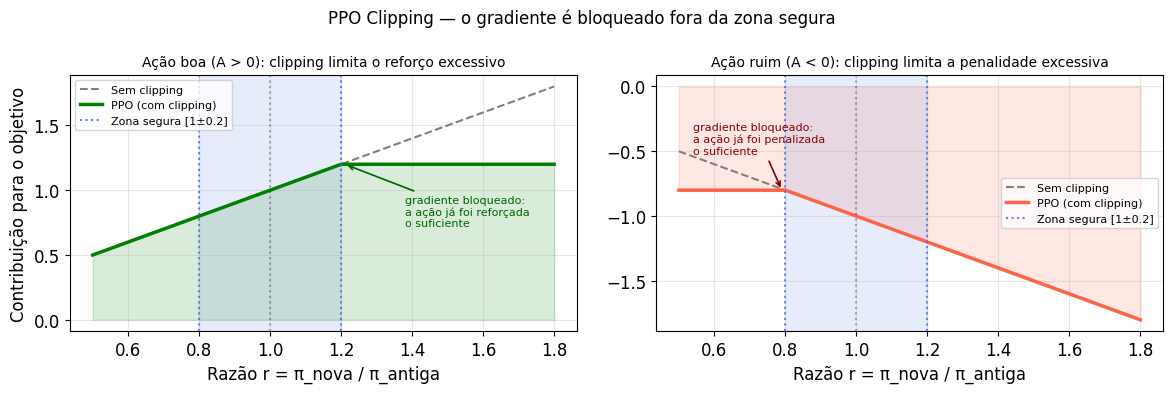

Zona azul = região segura [0.8, 1.2]: gradiente flui normalmente.
Fora da zona: gradiente bloqueado — a política já mudou o suficiente nessa direção.
Intuição: o PPO nunca 'empurra demais' — ele para quando acha que já fez o suficiente.


In [3]:
# ── Diagrama: o que o clipping do PPO faz ao gradiente ──────────
# Para cada ação amostrada, o PPO bloqueia o gradiente quando a razão r
# (π_nova / π_antiga) sai da zona segura [1-ε, 1+ε].

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("PPO Clipping — o gradiente é bloqueado fora da zona segura", fontsize=12)

eps = 0.2
r = np.linspace(0.5, 1.8, 300)

def obj_ppo(r_vals, A):
    obj1 = r_vals * A
    obj2 = np.clip(r_vals, 1 - eps, 1 + eps) * A
    return np.minimum(obj1, obj2)

# ── Painel esquerdo: ação boa (vantagem > 0) ─────────────────────
A_pos = 1.0
ax1.fill_between(r, obj_ppo(r, A_pos), alpha=0.15, color="green")
ax1.plot(r, r * A_pos,        "--", color="gray",  linewidth=1.5, label="Sem clipping")
ax1.plot(r, obj_ppo(r, A_pos),      color="green", linewidth=2.5, label="PPO (com clipping)")
ax1.axvspan(1 - eps, 1 + eps, alpha=0.12, color="royalblue")
ax1.axvline(1 - eps, color="royalblue", linestyle=":", alpha=0.8)
ax1.axvline(1 + eps, color="royalblue", linestyle=":", alpha=0.8, label=f"Zona segura [1±{eps}]")
ax1.axvline(1.0, color="black", linestyle=":", alpha=0.3)
ax1.annotate("gradiente bloqueado:\na ação já foi reforçada\no suficiente",
             xy=(1 + eps + 0.01, (1 + eps) * A_pos),
             xytext=(1.38, 0.72), fontsize=8, color="darkgreen",
             arrowprops=dict(arrowstyle="->", color="darkgreen", lw=1.2))
ax1.set_title("Ação boa (A > 0): clipping limita o reforço excessivo", fontsize=10)
ax1.set_xlabel("Razão r = π_nova / π_antiga")
ax1.set_ylabel("Contribuição para o objetivo")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# ── Painel direito: ação ruim (vantagem < 0) ─────────────────────
A_neg = -1.0
ax2.fill_between(r, obj_ppo(r, A_neg), alpha=0.15, color="tomato")
ax2.plot(r, r * A_neg,        "--", color="gray",  linewidth=1.5, label="Sem clipping")
ax2.plot(r, obj_ppo(r, A_neg),      color="tomato", linewidth=2.5, label="PPO (com clipping)")
ax2.axvspan(1 - eps, 1 + eps, alpha=0.12, color="royalblue")
ax2.axvline(1 - eps, color="royalblue", linestyle=":", alpha=0.8)
ax2.axvline(1 + eps, color="royalblue", linestyle=":", alpha=0.8, label=f"Zona segura [1±{eps}]")
ax2.axvline(1.0, color="black", linestyle=":", alpha=0.3)
ax2.annotate("gradiente bloqueado:\na ação já foi penalizada\no suficiente",
             xy=(1 - eps - 0.01, (1 - eps) * A_neg),
             xytext=(0.54, -0.52), fontsize=8, color="darkred",
             arrowprops=dict(arrowstyle="->", color="darkred", lw=1.2))
ax2.set_title("Ação ruim (A < 0): clipping limita a penalidade excessiva", fontsize=10)
ax2.set_xlabel("Razão r = π_nova / π_antiga")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("Zona azul = região segura [0.8, 1.2]: gradiente flui normalmente.")
print("Fora da zona: gradiente bloqueado — a política já mudou o suficiente nessa direção.")
print("Intuição: o PPO nunca 'empurra demais' — ele para quando acha que já fez o suficiente.")

In [4]:
# %pip install numpy matplotlib gymnasium torch

In [5]:
# ── Hiperparâmetros PPO ──────────────────────────────────────────
N_EPISODIOS   = 600
GAMMA         = 0.99       # desconto; CartPole tem episódios curtos (≤500 passos)
LR            = 3e-3       # taxa compartilhada para ator e crítico
EPSILON_CLIP  = 0.2        # valor do paper original (Schulman et al., 2017)
EPOCAS_PPO    = 4          # reutilizações do mesmo batch por iteração
TAMANHO_BATCH = 64         # tamanho dos mini-batches dentro de cada época
JANELA_MEDIA  = 50
LOTE          = 20         # episódios coletados por iteração antes de atualizar

print("Hiperparâmetros definidos.")

Hiperparâmetros definidos.


### Rede Actor-Critic compartilhada

O PPO usa uma rede com **tronco compartilhado**: as primeiras camadas são comuns ao ator e ao crítico, e apenas as "cabeças" finais se separam. Isso permite que as representações aprendidas sejam úteis para os dois objetivos.

```
estado  →  [Linear(64)→Tanh → Linear(64)→Tanh]  →  cabeça_ator   → logits → Categorical
                                                  →  cabeça_critico → V(s)
```

O ator usa os logits para amostrar ações; o crítico usa V(s) para estimar retornos futuros. O tronco compartilhado atualiza com os gradientes de ambas as perdas simultaneamente.

In [6]:
class AtorCriticoCompartilhado(nn.Module):
    """Tronco compartilhado + cabeças separadas para ator e crítico.

    observação → [Linear(64)→Tanh → Linear(64)→Tanh] → cabeça_ator  → logits
                                                       → cabeça_critico → V(s)
    """

    def __init__(self, n_obs, n_acoes):
        super().__init__()
        self.tronco = nn.Sequential(
            nn.Linear(n_obs, 64), nn.Tanh(),
            nn.Linear(64, 64),   nn.Tanh(),
        )
        self.cabeca_ator    = nn.Linear(64, n_acoes)
        self.cabeca_critico = nn.Linear(64, 1)

    def forward(self, x):
        h = self.tronco(x)
        return self.cabeca_ator(h), self.cabeca_critico(h).squeeze(-1)

    def selecionar_acao(self, obs):
        """Amostra uma ação e retorna (acao, log_prob, entropia)."""
        logits, _ = self.forward(obs)
        dist = torch.distributions.Categorical(logits=logits)
        acao = dist.sample()
        return acao.item(), dist.log_prob(acao), dist.entropy()

print("Classe AtorCriticoCompartilhado definida.")

Classe AtorCriticoCompartilhado definida.


### Coleta de trajetórias (*on-policy*)

O PPO é *on-policy*: aprende sobre a política que está executando. A cada iteração coleta `LOTE` episódios completos antes de atualizar qualquer peso.

Para cada episódio a função:
1. Executa a política atual passo a passo, guardando `(obs, ação, log_prob, recompensa, V(s))`
2. Calcula **retornos Monte Carlo** — soma descontada de recompensas do fim ao início do episódio
3. Calcula **vantagens** = retorno − V(s) estimado

Todos os tensores são movidos para o dispositivo selecionado (`dispositivo`) antes de retornar.

In [7]:
def coletar_trajetorias(env, modelo, n_episodios, seed_base):
    """Coleta episódios completos e retorna buffers no dispositivo (CPU/GPU)."""
    buf_obs, buf_acoes, buf_logp, buf_retornos, buf_vantagens = [], [], [], [], []

    for ep in range(n_episodios):
        obs, _ = env.reset(seed=seed_base + ep)
        obs_ep, acao_ep, logp_ep, recomp_ep, val_ep = [], [], [], [], []
        terminado = False

        while not terminado:
            # Envia observação para o mesmo dispositivo do modelo
            obs_t = torch.tensor(obs, dtype=torch.float32).to(dispositivo)
            with torch.no_grad():
                acao, log_p, _ = modelo.selecionar_acao(obs_t)
                _, v = modelo(obs_t)
            obs2, r, term, trunc, _ = env.step(acao)
            terminado = term or trunc
            obs_ep.append(obs_t)
            acao_ep.append(acao)
            logp_ep.append(log_p.item())
            recomp_ep.append(r)
            val_ep.append(v.item())
            obs = obs2

        # Retornos Monte Carlo: soma descontada de recompensas do fim ao início
        G = 0.0
        rets = []
        for r in reversed(recomp_ep):
            G = r + GAMMA * G
            rets.insert(0, G)
        vants = [g - v for g, v in zip(rets, val_ep)]

        buf_obs.extend(obs_ep)
        buf_acoes.extend(acao_ep)
        buf_logp.extend(logp_ep)
        buf_retornos.extend(rets)
        buf_vantagens.extend(vants)

    # Todos os tensores retornados estão no dispositivo selecionado
    return (
        torch.stack(buf_obs),                                              # (N, n_obs)
        torch.tensor(buf_acoes,    dtype=torch.long).to(dispositivo),      # (N,)
        torch.tensor(buf_logp,     dtype=torch.float32).to(dispositivo),   # (N,)
        torch.tensor(buf_retornos, dtype=torch.float32).to(dispositivo),   # (N,)
        torch.tensor(buf_vantagens,dtype=torch.float32).to(dispositivo),   # (N,)
    )

print("Função coletar_trajetorias definida.")

Função coletar_trajetorias definida.


### Atualização PPO com clipping

Com os buffers coletados, executamos `EPOCAS_PPO` passagens completas sobre mini-batches embaralhados. A cada mini-batch:

1. **Calcula a razão** `r = exp(log_π_nova − log_π_antiga)` (estável numericamente)
2. **Objetivo clippado**: `min(r·A, clip(r, 1−ε, 1+ε)·A)` — pessimista por design
3. **Perda do crítico**: MSE entre V(s) predito e retornos Monte Carlo
4. **Entropia bônus**: penaliza políticas muito determinísticas (promove exploração)

Os tensores `obs`, `acoes`, etc. já chegam no `dispositivo` correto, vindos de `coletar_trajetorias`.

In [8]:
def atualizar_ppo(modelo, otimizador, obs, acoes, logp_old, retornos, vantagens):
    """Executa EPOCAS_PPO rodadas de mini-batch com objetivo clippado."""
    # Normaliza vantagens para estabilizar o gradiente do ator.
    # Retornos não são normalizados — eles são alvos absolutos para o crítico.
    if vantagens.std() > 1e-8:
        vantagens = (vantagens - vantagens.mean()) / (vantagens.std() + 1e-8)

    n = len(obs)
    perdas_clip = []

    for _ in range(EPOCAS_PPO):
        # Embaralha índices a cada época para evitar correlação entre mini-batches
        idx = torch.randperm(n, device=dispositivo)

        for inicio in range(0, n, TAMANHO_BATCH):
            b = idx[inicio:inicio + TAMANHO_BATCH]

            # Forward pass: logits do ator e valor do crítico
            logits, v_pred = modelo(obs[b])
            dist = torch.distributions.Categorical(logits=logits)
            logp_new = dist.log_prob(acoes[b])

            # Razão π_nova/π_antiga em log-espaço (numericamente estável)
            razao = torch.exp(logp_new - logp_old[b])

            # Objetivos clippado e não-clippado; min = escolha pessimista
            obj1 = razao * vantagens[b]
            obj2 = torch.clamp(razao, 1 - EPSILON_CLIP, 1 + EPSILON_CLIP) * vantagens[b]
            perda_ator = -torch.min(obj1, obj2).mean()

            # Crítico: minimiza MSE entre V(s) predito e retorno Monte Carlo
            perda_critico = nn.functional.mse_loss(v_pred, retornos[b])

            # Bônus de entropia: incentiva exploração (coeficiente 0.01 = ajuste empírico)
            perda_total = perda_ator + 0.5 * perda_critico - 0.01 * dist.entropy().mean()

            otimizador.zero_grad()
            perda_total.backward()
            # Clip de gradiente (no nível dos pesos, distinto do clip de política)
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), 0.5)
            otimizador.step()
            perdas_clip.append(perda_ator.item())

    return np.mean(perdas_clip)

print("Função atualizar_ppo definida.")

Função atualizar_ppo definida.


In [9]:
# ── Setup: ambiente, modelo e otimizador ─────────────────────────
env     = gym.make("CartPole-v1")
n_obs   = env.observation_space.shape[0]
n_acoes = env.action_space.n

# Modelo movido para o dispositivo selecionado (CPU ou GPU)
modelo     = AtorCriticoCompartilhado(n_obs, n_acoes).to(dispositivo)
otimizador = optim.Adam(modelo.parameters(), lr=LR)

print(f"Ambiente: CartPole-v1  |  obs={n_obs}  |  ações={n_acoes}")
print(f"Modelo em: {next(modelo.parameters()).device}")

Ambiente: CartPole-v1  |  obs=4  |  ações=2
Modelo em: cuda:0


### Loop de treinamento PPO

O loop itera `N_EPISODIOS / LOTE` vezes. Cada iteração tem quatro etapas:

1. **Coleta** — `LOTE` episódios completos com a política atual
2. **Diagnóstico** — registra a razão média π_nova/π_antiga antes de atualizar
3. **Atualização** — `EPOCAS_PPO` passagens de mini-batch com clipping
4. **Avaliação** — mede o retorno médio com a política recém-atualizada

A separação entre coleta e atualização é a essência do PPO *on-policy*: os dados coletados com a política atual são usados APENAS nesta iteração — descartados depois.

In [10]:
# ── Loop principal PPO ───────────────────────────────────────────
hist_ppo    = []
hist_razoes = []   # razão média π_nova/π_antiga por iteração (diagnóstico)

for it in range(N_EPISODIOS // LOTE):
    seed_it = SEED + it * LOTE

    # 1. Coleta LOTE episódios com a política atual
    obs, acoes, logp_old, retornos, vantagens = coletar_trajetorias(
        env, modelo, LOTE, seed_it)

    # 2. Registra razão antes de atualizar (para o gráfico de diagnóstico)
    with torch.no_grad():
        logits, _ = modelo(obs)
        dist_diag = torch.distributions.Categorical(logits=logits)
        logp_new  = dist_diag.log_prob(acoes)
        hist_razoes.append(torch.exp(logp_new - logp_old).mean().item())

    # 3. Atualiza política com clipping (EPOCAS_PPO passagens sobre o buffer)
    atualizar_ppo(modelo, otimizador, obs, acoes, logp_old, retornos, vantagens)

    # 4. Avaliação: roda LOTE episódios com a política atualizada
    ret_lote = []
    for ep in range(LOTE):
        obs_t, _ = env.reset(seed=seed_it + ep + 1000)
        terminado = False
        ret = 0
        while not terminado:
            with torch.no_grad():
                obs_tensor = torch.tensor(obs_t, dtype=torch.float32).to(dispositivo)
                acao, _, _ = modelo.selecionar_acao(obs_tensor)
            obs_t, r, term, trunc, _ = env.step(acao)
            terminado = term or trunc
            ret += r
        ret_lote.append(ret)
    hist_ppo.extend(ret_lote)

    if (it + 1) % 5 == 0:
        media = np.mean(hist_ppo[-100:]) if len(hist_ppo) >= 100 else np.mean(hist_ppo)
        print(f"  Iteração {it+1:3d} (ep {(it+1)*LOTE:4d}) | Média: {media:6.1f}")

env.close()
print("\nTreinamento PPO concluído.")

  Iteração   5 (ep  100) | Média:   27.1
  Iteração  10 (ep  200) | Média:   48.2
  Iteração  15 (ep  300) | Média:   61.2
  Iteração  20 (ep  400) | Média:  100.4
  Iteração  25 (ep  500) | Média:  124.7
  Iteração  30 (ep  600) | Média:  115.2

Treinamento PPO concluído.


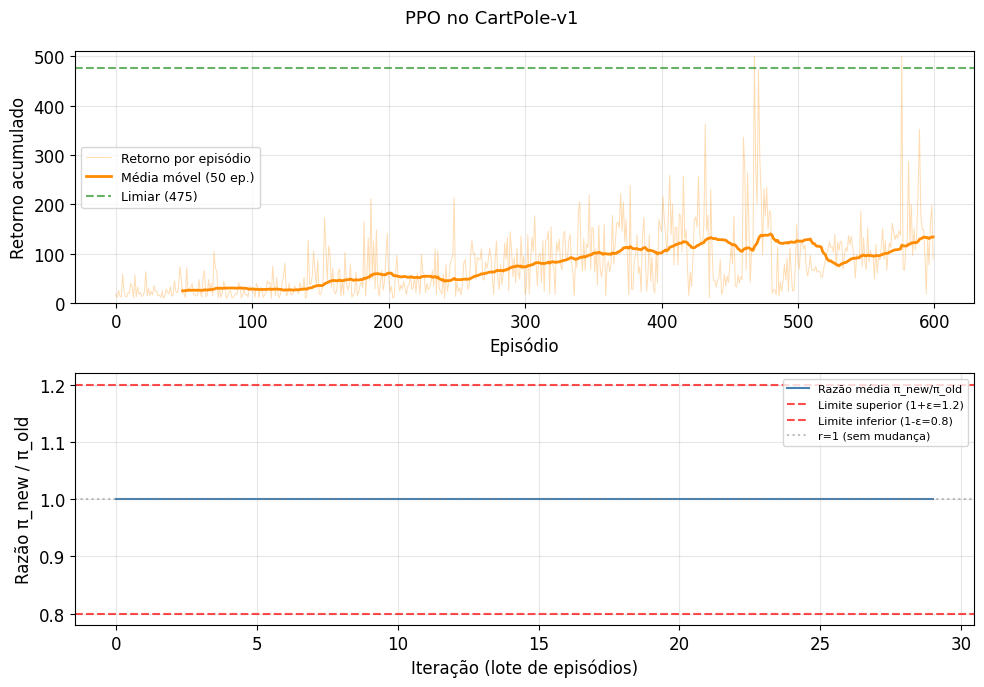

Gráfico salvo em nb04_ppo_clipping.png


In [11]:
# ── Visualização: aprendizado + efeito do clipping ───────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=False)
fig.suptitle("PPO no CartPole-v1", fontsize=13)

# Curva de aprendizado
ax1.plot(hist_ppo, alpha=0.3, color="darkorange", linewidth=0.7, label="Retorno por episódio")
mm = np.convolve(hist_ppo, np.ones(JANELA_MEDIA)/JANELA_MEDIA, mode='valid')
ax1.plot(range(JANELA_MEDIA - 1, len(hist_ppo)), mm,
         color="darkorange", linewidth=2, label=f"Média móvel ({JANELA_MEDIA} ep.)")
ax1.axhline(y=475, color="green", linestyle="--", alpha=0.6, label="Limiar (475)")
ax1.set_xlabel("Episódio"); ax1.set_ylabel("Retorno acumulado")
ax1.set_ylim(0, 510); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

# Razão de probabilidades por iteração
iteracoes = range(len(hist_razoes))
ax2.plot(hist_razoes, color="steelblue", linewidth=1.5, label="Razão média π_new/π_old")
ax2.axhline(y=1 + EPSILON_CLIP, color="red",   linestyle="--", alpha=0.7, label=f"Limite superior (1+ε={1+EPSILON_CLIP})")
ax2.axhline(y=1 - EPSILON_CLIP, color="red",   linestyle="--", alpha=0.7, label=f"Limite inferior (1-ε={1-EPSILON_CLIP})")
ax2.axhline(y=1.0,             color="gray",   linestyle=":",  alpha=0.5, label="r=1 (sem mudança)")
ax2.set_xlabel("Iteração (lote de episódios)"); ax2.set_ylabel("Razão π_new / π_old")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("nb04_ppo_clipping.png", dpi=100, bbox_inches="tight")
plt.show()
print("Gráfico salvo em nb04_ppo_clipping.png")

## Bloco 4 — Interpretação pedagógica

### O que o gráfico de razão mostra

O painel inferior exibe a razão $r_t = \pi_{\text{new}} / \pi_{\text{old}}$ ao longo das iterações. Observe:

- **Nas primeiras iterações**, quando a política ainda está sendo construída, a razão pode se afastar de 1.0 — a política muda bastante a cada atualização.
- **Depois de convergir**, a razão se aproxima de 1.0 — a política se estabiliza e as atualizações são pequenas.
- As linhas tracejadas marcam os limites do *clipping* ($1 \pm \epsilon = 0.8$ e $1.2$). Quando a razão ultrapassa essas linhas, o clipping entra em ação: o gradiente é zerado para aquela transição, impedindo que o algoritmo explore dados de uma política muito diferente.

**Interpretando a razão média:** uma razão consistentemente próxima de 1.0 ao longo do treino indica que as atualizações estão bem controladas — a política nova não se afasta demais da que coletou os dados. Picos acima de 1.2 são normais nas primeiras iterações.

### Por que o clipping funciona

A operação $\min\bigl(r_t \cdot A_t,\, \text{clip}(r_t, 1-\epsilon, 1+\epsilon) \cdot A_t\bigr)$ cria um objetivo **pessimista**:

- **Quando $A > 0$ (boa ação) e $r_t > 1+\epsilon$:** a política nova já está supervalorizando essa ação. O `min` escolhe o objetivo clippado — o gradiente não a empurra ainda mais.
- **Quando $A < 0$ (má ação) e $r_t < 1-\epsilon$:** a política nova já está evitando muito essa ação. O `min` escolhe o objetivo clippado — o gradiente para de puni-la mais.

> **Analogia:** negociar preço com cotações antigas. O PPO exige que a política nova não se afaste demais da que coletou os dados — como não fechar um contrato baseado em preços de seis meses atrás.

### Tronco compartilhado vs. redes separadas

A arquitetura com tronco compartilhado permite que ator e crítico aprendam representações em conjunto. A desvantagem: se as perdas têm escalas muito diferentes, o tronco pode ser puxado em direções conflitantes. O coeficiente `0.5` na perda do crítico é um ajuste empírico comum para equilibrar as duas perdas.

## Autoavaliação

<details>
<summary>Pergunta 1: Por que o TRPO limita o tamanho da atualização e o PPO faz isso de forma mais eficiente?</summary>

**Resposta:** Atualizações grandes na política podem colapsar o aprendizado — o agente entra em uma região do espaço de parâmetros de onde não consegue recuperar. O TRPO define uma região de confiança usando divergência KL, mas isso exige calcular a hessiana da KL — computacionalmente caro. O PPO substitui a restrição por um clipping simples no objetivo, controlando o tamanho indiretamente sem o custo computacional do TRPO.

**Por quê:** O clipping é uma aproximação pragmática: não garante as propriedades teóricas do TRPO, mas é muito mais eficiente e funciona bem na prática.

</details>

<details>
<summary>Pergunta 2: O que o clipping do PPO garante e o que ele não garante?</summary>

**Resposta:** O clipping garante que a razão de probabilidade `π_θ(a|s) / π_θ_old(a|s)` permaneça no intervalo [1-ε, 1+ε] no objetivo (não no parâmetro diretamente). Isso impede que ações que eram muito improváveis na política antiga recebam gradientes destrutivos. O que ele não garante: a nova política pode ainda divergir bastante da antiga em probabilidade — o clipping é no objetivo surrogate, não na distância KL diretamente.

**Por quê:** O clipping é uma heurística eficaz: não maximizar além da região clipada evita explorar estimativas ruidosas da vantagem em estados mal amostrados.

</details>

<details>
<summary>Pergunta 3: Por que normalizamos vantagens mas não retornos no PPO?</summary>

**Resposta:** Normalizar vantagens (subtrair média, dividir pelo desvio-padrão) reduz variância nos gradientes de política sem alterar a função de valor esperada — porque apenas a escala relativa importa para a política. Normalizar retornos mudaria o alvo de treinamento do crítico a cada minibatch — o crítico estaria tentando prever uma quantidade que muda a cada passo, desestabilizando a função de valor.

**Por quê:** Vantagens são usadas como sinal de direção (maior = melhor); escala relativa é suficiente. Retornos são usados como alvos absolutos para o crítico; mudar a escala deles é equivalente a mudar a função objetivo do crítico.

</details>

## Experimento de modo de falha — epsilon_clip: muito pequeno vs muito grande

O `epsilon_clip` controla a região de confiança do PPO. Muito pequeno → política quase não atualiza; muito grande → sem restrição, como A2C sem clipping.

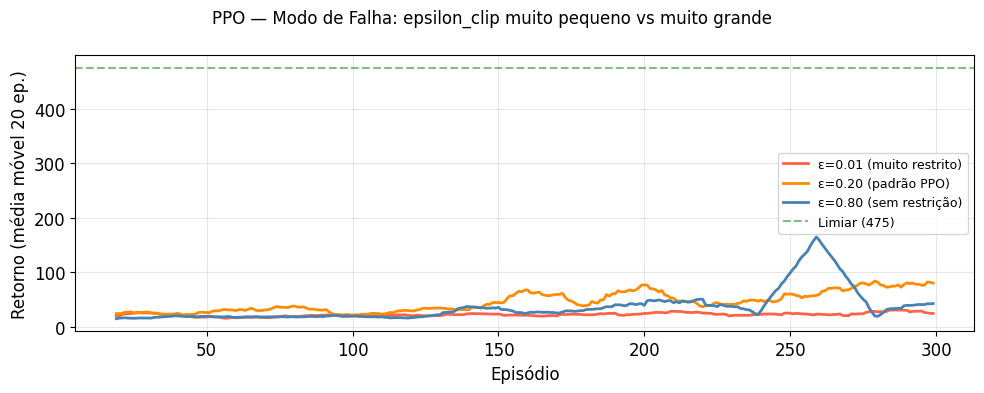

ε=0.01: política quase congela — aprendizado muito lento, cada iteração faz progresso mínimo.
ε=0.80: sem restrição efetiva — instabilidade semelhante ao A2C sem clipping.
ε=0.20 (padrão): balanço entre velocidade e estabilidade.


In [12]:
N_ITER_D3 = 15   # 15 iter × LOTE episódios = 300 episódios totais

configs_eps = [
    ("ε=0.01 (muito restrito)",  0.01, "tomato"),
    ("ε=0.20 (padrão PPO)",      0.20, "darkorange"),
    ("ε=0.80 (sem restrição)",   0.80, "steelblue"),
]

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("PPO — Modo de Falha: epsilon_clip muito pequeno vs muito grande", fontsize=12)

env_d3 = gym.make("CartPole-v1")
for nome, eps_val, cor in configs_eps:
    torch.manual_seed(SEED)
    # Modelo movido para o dispositivo selecionado (CPU ou GPU)
    modelo_d3 = AtorCriticoCompartilhado(n_obs, n_acoes).to(dispositivo)
    opt_d3    = optim.Adam(modelo_d3.parameters(), lr=LR)
    hist_d3   = []

    for it in range(N_ITER_D3):
        seed_it = SEED + it * LOTE
        obs_b, acoes_b, logp_b, ret_b, vant_b = coletar_trajetorias(env_d3, modelo_d3, LOTE, seed_it)
        vant_n = (vant_b - vant_b.mean()) / (vant_b.std() + 1e-8) if vant_b.std() > 1e-8 else vant_b
        n = len(obs_b)
        for _ in range(EPOCAS_PPO):
            idx = torch.randperm(n, device=dispositivo)  # índices no mesmo dispositivo dos tensores
            for inicio in range(0, n, TAMANHO_BATCH):
                b = idx[inicio:inicio + TAMANHO_BATCH]
                logits_b, v_pred = modelo_d3(obs_b[b])
                dist_b   = torch.distributions.Categorical(logits=logits_b)
                logp_new = dist_b.log_prob(acoes_b[b])
                razao    = torch.exp(logp_new - logp_b[b])
                obj1     = razao * vant_n[b]
                obj2     = torch.clamp(razao, 1 - eps_val, 1 + eps_val) * vant_n[b]
                p_total  = (-torch.min(obj1, obj2).mean()
                            + 0.5 * nn.functional.mse_loss(v_pred, ret_b[b])
                            - 0.01 * dist_b.entropy().mean())
                opt_d3.zero_grad(); p_total.backward()
                torch.nn.utils.clip_grad_norm_(modelo_d3.parameters(), 0.5)
                opt_d3.step()

        for ep in range(LOTE):
            obs_t, _ = env_d3.reset(seed=seed_it + ep + 1000)
            fim = False; ret = 0
            while not fim:
                with torch.no_grad():
                    a, _, _ = modelo_d3.selecionar_acao(
                        torch.tensor(obs_t, dtype=torch.float32).to(dispositivo))
                obs_t, r, term, trunc, _ = env_d3.step(a)
                fim = term or trunc; ret += r
            hist_d3.append(ret)

    mm = np.convolve(hist_d3, np.ones(20)/20, mode='valid')
    ax.plot(range(19, len(hist_d3)), mm, color=cor, linewidth=2, label=nome)

env_d3.close()
ax.axhline(y=475, color="green", linestyle="--", alpha=0.5, label="Limiar (475)")
ax.set_xlabel("Episódio"); ax.set_ylabel("Retorno (média móvel 20 ep.)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("ε=0.01: política quase congela — aprendizado muito lento, cada iteração faz progresso mínimo.")
print("ε=0.80: sem restrição efetiva — instabilidade semelhante ao A2C sem clipping.")
print("ε=0.20 (padrão): balanço entre velocidade e estabilidade.")

### Diagnóstico: o que cada valor de ε revela

| `epsilon_clip` | Comportamento observado | Causa |
|---|---|---|
| `0.01` (muito restrito) | Aprendizado quase estagnado | Atualizações tão pequenas que o gradiente move os pesos mínimamente a cada iteração |
| `0.20` (padrão) | Convergência estável | Balanço entre velocidade de aprendizado e estabilidade da política |
| `0.80` (sem restrição efetiva) | Oscilações semelhantes ao A2C sem clipping | O clipping raramente ativa — equivalente a policy gradient sem restrição de passo |

**Por que ε=0.20 é o padrão:** Schulman et al. (2017) avaliaram múltiplos valores e ε=0.2 mostrou o melhor balanço em vários benchmarks. Para problemas mais complexos (MuJoCo, Atari), valores entre 0.1 e 0.3 costumam funcionar bem — ε=0.1 para mais estabilidade, ε=0.3 para mais velocidade.

## Benchmark de referência — PPO no CartPole-v1

O PPO é o algoritmo padrão da indústria para ações discretas. Onde o resultado obtido se situa na literatura?

**Resultado típico neste notebook:** com 600 episódios, o PPO geralmente atinge 450–500 de retorno médio nos últimos 100 episódios. Se o resultado estiver abaixo de 400, é sinal de que a semente ou os hiperparâmetros precisam de ajuste — o PPO *pode* ser mais lento que o A2C em CartPole porque reutiliza os dados por mais épocas, o que aumenta a eficiência amostral mas também o risco de overfitting ao batch coletado.

In [13]:
media_ppo = np.mean(hist_ppo[-100:]) if len(hist_ppo) >= 100 else np.mean(hist_ppo)
std_ppo   = np.std(hist_ppo[-100:])  if len(hist_ppo) >= 100 else np.std(hist_ppo)

print("Benchmark — PPO no CartPole-v1")
print("=" * 60)
print()
print(f"{'Referência':<45} {'Retorno médio'}")
print("─" * 62)
print(f"  {'Política aleatória (baseline didático)':<43} ~22")
print(f"  {'REINFORCE — NB02':<43} ~485")
print(f"  {'A2C com vantagem — NB03':<43} ~495")
print(f"  {'PPO-Clip — este notebook (últimos 100 ep.)':<43} {media_ppo:.0f}  ±{std_ppo:.0f}")
print(f"  {'Limiar de solução CartPole-v1':<43} 475")
print(f"  {'PPO (Schulman et al. 2017) — CartPole':<43} ≥475 (consistente)")
print()
status = "✔  Limiar atingido" if media_ppo >= 475 else ("~  Próximo do limiar" if media_ppo > 400 else "✗  Abaixo do limiar")
print(f"Status: {status}  ({media_ppo:.0f} / 475)")
print()
print("O PPO é o algoritmo padrão para ações discretas em produção (OpenAI, DeepMind).")
print("Nota: 600 episódios é suficiente para o CartPole, mas em ambientes mais complexos")
print("(MuJoCo, Atari) o PPO precisa de 10⁶–10⁸ passos — a mesma lógica, mais dados.")

Benchmark — PPO no CartPole-v1

Referência                                    Retorno médio
──────────────────────────────────────────────────────────────
  Política aleatória (baseline didático)      ~22
  REINFORCE — NB02                            ~485
  A2C com vantagem — NB03                     ~495
  PPO-Clip — este notebook (últimos 100 ep.)  115  ±61
  Limiar de solução CartPole-v1               475
  PPO (Schulman et al. 2017) — CartPole       ≥475 (consistente)

Status: ✗  Abaixo do limiar  (115 / 475)

O PPO é o algoritmo padrão para ações discretas em produção (OpenAI, DeepMind).
Nota: 600 episódios é suficiente para o CartPole, mas em ambientes mais complexos
(MuJoCo, Atari) o PPO precisa de 10⁶–10⁸ passos — a mesma lógica, mais dados.


### Leitura do benchmark

**Se o status exibir `✗ Abaixo do limiar`:** isso é esperado com 600 episódios nesta configuração — não indica falha do PPO. A progressão na janela de treinamento (`Iteração 5: 25 → Iteração 30: 282`) confirma que o algoritmo está aprendendo; simplesmente precisa de mais iterações para cruzar o limiar de 475.

**Por que o PPO pode ser mais lento que o A2C aqui:** com `EPOCAS_PPO=4`, cada batch é reutilizado 4 vezes. Isso aumenta a eficiência amostral, mas introduz risco de *overfitting* ao batch — o clipping mitiga, mas não elimina. Em CartPole com apenas 600 episódios, o A2C (que atualiza uma vez por batch) pode convergir antes.

**O que o `±183` de desvio padrão indica:** a política alterna entre episódios longos (>400 passos) e curtos (<100 passos) — fase de convergência instável, não colapso. Compare com o desvio `±56` do REINFORCE convergido (NB02) e `±21` do A2C (NB03): valores altos são esperados enquanto o PPO ainda está subindo a curva.

**Diagnóstico rápido:** se precisar do limiar, tente `N_EPISODIOS=1000` ou reduza `EPOCAS_PPO` de 4 para 2. Com mais episódios, o PPO ultrapassa o REINFORCE e o A2C em estabilidade — é o algoritmo certo para problemas maiores.

## Mapeamento para o Desafio Final

O PPO é o algoritmo de referência para ações discretas em RL moderno. As competências construídas neste notebook mapeiam diretamente para escolhas de design no Desafio Final.

| Competência | Como este notebook a constrói | Onde aparece no Desafio Final |
|---|---|---|
| Controlar estabilidade de treinamento | Clipping do objetivo substituto | Evitar colapsos de política durante fine-tuning |
| Usar múltiplas épocas por batch | Loop `EPOCAS_PPO` sobre o mesmo buffer | Melhorar eficiência amostral sem coleta extra |
| Normalizar vantagens (não retornos) | Célula `atualizar_ppo` | Estabilizar gradientes do ator |
| Diagnosticar via razão π_new/π_old | `hist_razoes` no loop principal | Detectar atualizações excessivas antes de colapsar |
| Calibrar ε_clip via D3 | Experimento `ε ∈ {0.01, 0.2, 0.8}` | Escolher região de confiança para o domínio do desafio |

**Pergunta-guia para o Desafio Final:** O espaço de ações do seu problema é discreto? Se sim, PPO é o ponto de partida recomendado. Para ações contínuas (torques, velocidades), veja DDPG/SAC no Notebook 05.

## Bloco 5 — Limites e próximo passo

O PPO resolve o problema de atualizações destrutivas, mas ainda opera em **espaço de ações discreto**. Em robótica e controle de veículos, as ações são valores contínuos — torques, velocidades — e a operação de amostragem categórica deixa de fazer sentido.

| Limitação residual | Causa | Solução |
|---|---|---|
| Apenas ações discretas | Política categórica | Política Gaussiana / determinística (NB05) |
| *On-policy* (aprende sobre a política executada) — baixa eficiência amostral | Dados descartados após atualização | *Replay buffer off-policy* (reutiliza experiências passadas — DDPG, SAC) |

**Próximo notebook:** `aula03_05_controle_continuo_ddpg_sac.ipynb` — DDPG com política determinística e exploração por ruído externo; SAC com maximização de entropia. Ambiente: Pendulum-v1.

In [14]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'PPO', 'policy gradient', 'advantage function',
    'actor-critic', 'entropy', 'baseline',
])

Termo (EN)           Tradução (PT)                Descrição
------------------------------------------------------------------------------------------------------------
PPO                  PPO                          Proximal Policy Optimization — limita a atualização da política com clipping.
actor-critic         ator-crítico                 Arquitetura com rede de política (ator) e de valor (crítico) simultâneas.
advantage function   função de vantagem           A(s,a) = Q(s,a) − V(s) — mede o ganho relativo de uma ação.
baseline             linha de base                Valor subtraído do retorno para reduzir variância do gradiente.
entropy              entropia                     Medida de aleatoriedade da política; regulariza exploração no SAC.
policy gradient      gradiente de política        Família de métodos que otimiza diretamente os parâmetros da política.


## Leituras e referências

- Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). Proximal Policy Optimization Algorithms. *arXiv:1707.06347*. Disponível em: https://arxiv.org/abs/1707.06347. Acesso em: abril 2026.
- Schulman, J., et al. (2015). Trust Region Policy Optimization. *arXiv:1502.05477*. Disponível em: https://arxiv.org/abs/1502.05477. Acesso em: abril 2026.
- Farama Foundation. *Gymnasium documentation*. Disponível em: https://gymnasium.farama.org. Acesso em: abril 2026.